# Moving-Window GLCM Texture Analysis and K-Means Clustering

**Course project, GNR 607 (Satellite Image Processing).**

This notebook is both the runnable pipeline and the project report. Every number, table, figure
and interpretation below is produced by the code in `src/` when the notebook runs, so the
conclusions follow the actual results.

**Input image:** a public-domain 1946 aerial photograph of the Darling Downs district (Queensland),
showing fields, drainage lines and tree-covered areas (State Library of Queensland, via Wikimedia
Commons). It was centre-cropped to 512 x 512 pixels at native resolution by `src/download_sample.py`.
To use another image, change `IMAGE_PATH` in the configuration cell. RGB or multiband images are
converted to grayscale automatically.

In [1]:
import sys, time
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import config
from preprocess import load_image, smooth_image
from glcm import (quantize_image, angle_to_offset, compute_glcm, normalize_glcm, compute_asm,
                  compute_contrast, compute_mean, moving_window_glcm, moving_window_glcm_naive,
                  window_mean_direct)
from pipeline import run_experiment
from visualize import (plot_input_summary, plot_quantized, plot_texture_set, plot_clusters,
                       plot_smoothing, plot_histograms, plot_comparison_grid, feature_limits)

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 90

# ---------------- configuration (edit here) ----------------
IMAGE_PATH       = config.DEFAULT_IMAGE
GLCM_WINDOW_SIZE = 7
GRAY_LEVELS      = 8
DISTANCE         = 1
ANGLE            = 0
NUM_CLUSTERS     = 4
SMOOTHING_SIZES  = [7, 9]
OUTPUT_DIR       = config.OUTPUT_DIR
OFFSET = angle_to_offset(DISTANCE, ANGLE)
print("GLCM offset (dr, dc):", OFFSET)

GLCM offset (dr, dc): (0, 1)


## 1. Objective

1. Compute local texture with a **moving-window GLCM**: a separate co-occurrence matrix for every
   window position, not one GLCM for the whole image.
2. From each local GLCM, derive **ASM**, **Contrast (CON)** and **Mean**, giving three texture images.
3. Cluster the per-pixel feature vectors $[ASM, CON, MEAN]$ with **K-Means**.
4. Smooth the image with **7x7** and **9x9** averaging filters and repeat the whole analysis with identical parameters.
5. Compare the three cases visually and quantitatively, and explain how smoothing changes texture and clustering.

## 2. Methodology

```
Input image ──> Gray-level quantisation (L levels)
            ──> Moving window (w x w, pixel by pixel, reflect padding)
            ──> Local GLCM for offset (dr, dc) ──> normalise to P(i,j)
            ──> ASM | Contrast | Mean   (one value per window = per pixel)
            ──> Texture feature images
            ──> Feature vector per pixel x = [ASM, CON, MEAN]
            ──> Standardisation (z-score)
            ──> K-Means (K clusters) ──> Texture cluster map

Repeated for:  Original  |  7x7 averaged  |  9x9 averaged     (same GLCM + K-Means parameters)
```

## 3. Input image

File        : /Users/harishbisht/Documents/GNR607/data/aerial_sample.png
Dimensions  : 512 x 512 pixels (W x H)
Min / Max   : 14.0 / 240.0
Mean / Std  : 135.98 / 54.89


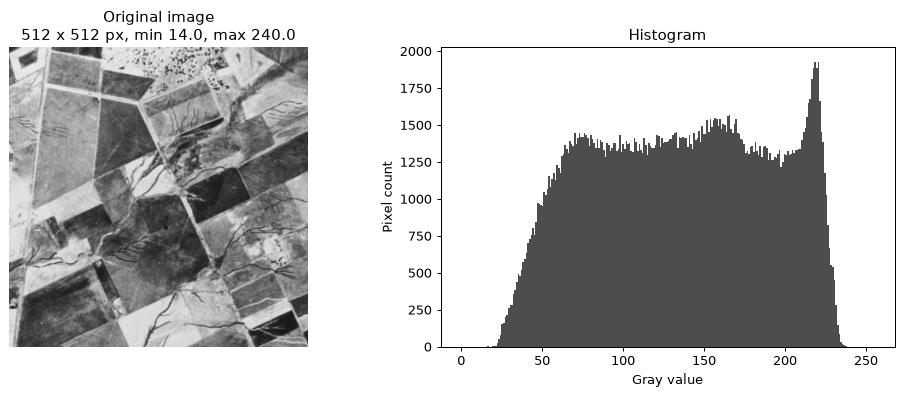

In [2]:
image = load_image(IMAGE_PATH)
print(f"File        : {IMAGE_PATH}")
print(f"Dimensions  : {image.shape[1]} x {image.shape[0]} pixels (W x H)")
print(f"Min / Max   : {image.min():.1f} / {image.max():.1f}")
print(f"Mean / Std  : {image.mean():.2f} / {image.std():.2f}")
plot_input_summary(image, "Original image", show=True)

### 3.1 Gray-level quantisation

Before building GLCMs, the 8-bit gray values are mapped linearly to $L$ levels:

$$
q(x,y) = \min\!\left(L-1,\; \left\lfloor \frac{I(x,y) - I_{lo}}{I_{hi} - I_{lo}}\, L \right\rfloor\right),
\qquad q \in \{0,\dots,L-1\}.
$$

**Why quantise?**

* A GLCM has $L^2$ cells: $256^2 = 65{,}536$ for 8-bit data versus $8^2 = 64$ for $L = 8$.
* A 7x7 window with offset $(0,1)$ contains only $7 \times 6 = 42$ pixel pairs. With 256 levels
  almost every cell would be 0 or 1 and the probabilities would be pure noise. With 8 levels the
  42 pairs give a meaningful probability estimate.
* Memory and computation scale with $L^2$, and texture measures become less sensitive to small
  intensity noise.

$I_{lo}$ and $I_{hi}$ are taken from the **original** image and reused for the smoothed images,
so a given level means the same intensity band in all three experiments. Quantising the whole
image once with this mapping gives exactly the same result as quantising every window patch with it.

Quantised levels present: [0 1 2 3 4 5 6 7]


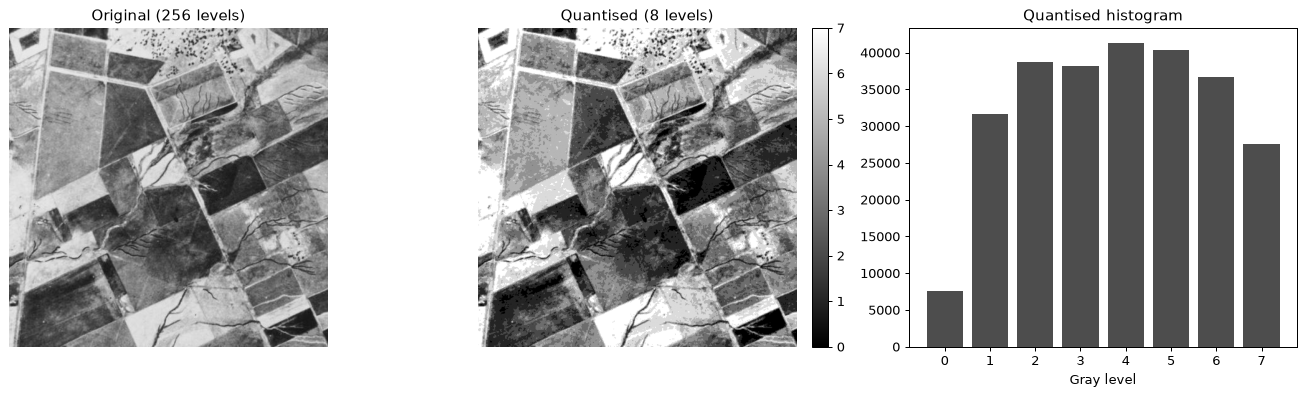

In [3]:
lo, hi = image.min(), image.max()
q = quantize_image(image, GRAY_LEVELS, lo, hi)
print("Quantised levels present:", np.unique(q))
plot_quantized(image, q, GRAY_LEVELS, show=True)

## 4. GLCM: definition

For a displacement $\delta = (d_r, d_c)$ (distance $d$, angle $\theta$), the GLCM of a region $W$ counts
how often a pixel with level $i$ has a neighbour at $\delta$ with level $j$:

$$
\mathrm{GLCM}_\delta(i,j) = \#\{\, (p,\, p+\delta) : p \in W,\; p+\delta \in W,\; q(p)=i,\; q(p+\delta)=j \,\}.
$$

Default here: $d=1$, $\theta=0^\circ$, i.e. $\delta=(0,1)$ (right-hand neighbour). The function
`angle_to_offset` maps $0^\circ \to (0,d)$, $45^\circ \to (-d,d)$, $90^\circ \to (-d,0)$ and
$135^\circ \to (-d,-d)$, so the relationship is easy to change. A symmetric GLCM
($\mathrm{GLCM} + \mathrm{GLCM}^T$) is available as an option. The default is the non-symmetric matrix defined above.

**Normalisation.** The matrix is turned into a joint probability distribution:

$$
P(i,j) = \frac{\mathrm{GLCM}(i,j)}{\sum_{i}\sum_{j} \mathrm{GLCM}(i,j)}, \qquad \sum_{i,j} P(i,j) = 1.
$$

For a $w \times w$ window and $\theta = 0^\circ$, the number of valid pairs is $w(w-d)$ (42 for $w=7, d=1$).
If a window had no valid pairs (e.g. $d \ge w$), `normalize_glcm` returns an all-zero matrix and every
feature is 0, so there is never a division by zero.

### 4.1 Worked example: the GLCM is computed *locally*

Below, two individual 7x7 windows are taken from different parts of the image. Each gets its own
GLCM and its own feature values. The pixel at the window centre receives these values in the texture images.

In [4]:
half = GLCM_WINDOW_SIZE // 2
q_pad = np.pad(q, half, mode="reflect")

def local_window_report(r, c):
    patch = q_pad[r:r + GLCM_WINDOW_SIZE, c:c + GLCM_WINDOW_SIZE]     # window centred on (r, c)
    G = compute_glcm(patch, GRAY_LEVELS, OFFSET)
    P = normalize_glcm(G)
    feats = dict(ASM=compute_asm(P), CON=compute_contrast(P), MEAN=compute_mean(P))
    return patch, G, P, feats

# pick an interior pixel with maximum ASM (uniform) and one with maximum contrast (textured)
pick = moving_window_glcm(q, GLCM_WINDOW_SIZE, GRAY_LEVELS, OFFSET)
inner = (slice(50, -50), slice(50, -50))
r1, c1 = np.unravel_index(np.argmax(pick["ASM"][inner]), pick["ASM"][inner].shape)
r2, c2 = np.unravel_index(np.argmax(pick["CON"][inner]), pick["CON"][inner].shape)
locs = [(r1 + 50, c1 + 50, "uniform window"), (r2 + 50, c2 + 50, "textured window")]

for r, c, name in locs:
    patch, G, P, f = local_window_report(r, c)
    print(f"=== {name} centred at (row={r}, col={c}) ===")
    print("Quantised 7x7 patch:\n", patch)
    print(f"GLCM counts (sum = {G.sum()} pairs):")
    display(pd.DataFrame(G, index=[f"i={i}" for i in range(GRAY_LEVELS)],
                         columns=[f"j={j}" for j in range(GRAY_LEVELS)]))
    print("ASM = {ASM:.4f}   CON = {CON:.4f}   MEAN = {MEAN:.4f}\n".format(**f))

=== uniform window centred at (row=50, col=149) ===
Quantised 7x7 patch:
 [[4 4 4 4 4 4 4]
 [4 4 4 4 4 4 4]
 [4 4 4 4 4 4 4]
 [4 4 4 4 4 4 4]
 [4 4 4 4 4 4 4]
 [4 4 4 4 4 4 4]
 [4 4 4 4 4 4 4]]
GLCM counts (sum = 42 pairs):


,j=0,j=1,j=2,j=3,j=4,j=5,j=6,j=7
i=0,0,0,0,0,0,0,0,0
i=1,0,0,0,0,0,0,0,0
i=2,0,0,0,0,0,0,0,0
i=3,0,0,0,0,0,0,0,0
i=4,0,0,0,0,42,0,0,0
i=5,0,0,0,0,0,0,0,0
i=6,0,0,0,0,0,0,0,0
i=7,0,0,0,0,0,0,0,0


ASM = 1.0000   CON = 0.0000   MEAN = 4.0000

=== textured window centred at (row=438, col=275) ===
Quantised 7x7 patch:
 [[7 7 6 4 2 1 3]
 [7 6 6 3 1 3 5]
 [7 6 4 2 1 4 5]
 [7 6 3 1 2 4 6]
 [6 5 2 1 3 5 6]
 [6 4 2 2 5 6 7]
 [5 2 1 3 6 7 7]]
GLCM counts (sum = 42 pairs):


,j=0,j=1,j=2,j=3,j=4,j=5,j=6,j=7
i=0,0,0,0,0,0,0,0,0
i=1,0,0,1,4,1,0,0,0
i=2,0,4,1,0,1,1,0,0
i=3,0,2,0,0,0,2,1,0
i=4,0,0,3,0,0,1,1,0
i=5,0,0,2,0,0,0,2,0
i=6,0,0,0,2,3,1,1,2
i=7,0,0,0,0,0,0,4,2


ASM = 0.0590   CON = 3.3810   MEAN = 4.0714



The textured window spreads its pairs over many GLCM cells, often far from the diagonal, giving low
ASM and high contrast. The uniform window concentrates its pairs in one or a few diagonal cells,
giving high ASM and near-zero contrast. A single image-wide GLCM would average these regions away.
The moving window keeps them apart.

## 5. Moving-window implementation

* **Window movement:** the window moves **one pixel at a time** over every row and column. For output
  pixel $(r,c)$ it covers rows $r-\lfloor w/2\rfloor \dots r+\lfloor w/2\rfloor$ (same for columns).
* **Boundary handling:** the quantised image is **reflect-padded** by $\lfloor w/2 \rfloor$ pixels
  (`np.pad(..., mode="reflect")`). Every pixel, including those at the border, therefore has a full
  window with the same number of pairs, and the texture images have **the same size as the input**.
  Reflection avoids the artificial edges that zero padding would add (zero padding would create fake
  high-contrast transitions).
* **Only pairs whose two pixels are both inside the window** are counted.

Two implementations are provided:

1. `moving_window_glcm_naive`, the reference version: a double loop over all positions, calling
   `compute_glcm` → `normalize_glcm` → feature functions for each patch.
2. `moving_window_glcm`, the optimised version. It computes the **same local GLCMs**:
   * each pixel pair is encoded as $k = i \cdot L + j$;
   * for every code, an indicator image is box-summed over each window's valid reference region
     with an **integral image** (cumulative sums), $O(1)$ per window;
   * the box sum at $(r,c)$ is exactly $\mathrm{GLCM}_{(r,c)}(i,j)$;
   * features are accumulated code by code, so memory stays $O(HW)$.

   No library GLCM or texture function is used.

The next cell verifies that both implementations agree exactly and compares their run time.

In [5]:
crop = q[200:264, 200:264]
t0 = time.perf_counter(); A = moving_window_glcm_naive(crop, GLCM_WINDOW_SIZE, GRAY_LEVELS, OFFSET, return_glcm=True); t_naive = time.perf_counter() - t0
t0 = time.perf_counter(); B = moving_window_glcm(crop, GLCM_WINDOW_SIZE, GRAY_LEVELS, OFFSET, return_glcm=True); t_vec = time.perf_counter() - t0
for k in ("GLCM", "ASM", "CON", "MEAN"):
    assert np.allclose(A[k], B[k]), k
print(f"64x64 crop: naive {t_naive:.3f} s, vectorised {t_vec:.4f} s  ->  identical local GLCMs and features")
print("Every local GLCM sums to 1:", np.allclose(B["GLCM"].sum(axis=(-2, -1)), 1))

t0 = time.perf_counter(); full = moving_window_glcm(q, GLCM_WINDOW_SIZE, GRAY_LEVELS, OFFSET); t_full = time.perf_counter() - t0
print(f"Full {q.shape[0]}x{q.shape[1]} image ({q.size:,} windows): vectorised {t_full:.2f} s; "
      f"naive would take about {t_naive * q.size / crop.size:.0f} s")

# the vectorised result reproduces the worked examples above
for r, c, name in locs:
    _, _, _, f = local_window_report(r, c)
    assert np.isclose(full["ASM"][r, c], f["ASM"]) and np.isclose(full["CON"][r, c], f["CON"])
print("Worked-example windows match the texture images at their centre pixels.")

64x64 crop: naive 0.073 s, vectorised 0.0027 s  ->  identical local GLCMs and features
Every local GLCM sums to 1: True
Full 512x512 image (262,144 windows): vectorised 0.10 s; naive would take about 5 s
Worked-example windows match the texture images at their centre pixels.


## 6. Texture features

All three are computed from the normalised local GLCM $P(i,j)$ of each window ($i,j = 0..L-1$).

### 6.1 ASM (Angular Second Moment / energy)

$$ \mathrm{ASM} = \sum_{i=0}^{L-1}\sum_{j=0}^{L-1} P(i,j)^2 $$

* Range $[1/N_{cells}, 1]$. ASM $=1$ when all pairs fall in a single cell (perfectly uniform window).
* Low ASM means the pairs are spread over many cells (heterogeneous texture).

### 6.2 Contrast (CON)

$$ \mathrm{CON} = \sum_{i=0}^{L-1}\sum_{j=0}^{L-1} (i-j)^2\, P(i,j) $$

* Weights each pair by the squared level difference. Pairs on the diagonal ($i=j$) contribute nothing.
* High contrast means strong local gray-level variation (edges, fine texture). Range $[0, (L-1)^2]$.

### 6.3 Mean (GLCM mean)

$$ \mathrm{MEAN} = \mu_x = \sum_{i=0}^{L-1} i\, P_x(i), \qquad P_x(i) = \sum_{j=0}^{L-1} P(i,j). $$

* **Definition used:** the GLCM marginal (reference-pixel) mean, expressed in quantised levels $0..L-1$.
* $P_x$ is the gray-level distribution of the reference pixels of all valid pairs. For $\theta=0^\circ$
  these are the first $w-1$ columns of the window.
* It is therefore very close to, but not identical with, the plain average of the quantised window
  (`window_mean_direct`). The cross-check below compares the two.

In [6]:
direct = window_mean_direct(q, GLCM_WINDOW_SIZE)
diff = np.abs(full["MEAN"] - direct)
print(f"GLCM mean vs direct window mean: correlation = {np.corrcoef(full['MEAN'].ravel(), direct.ravel())[0,1]:.4f}, "
      f"mean |diff| = {diff.mean():.4f} levels, max |diff| = {diff.max():.4f} levels")

GLCM mean vs direct window mean: correlation = 0.9987, mean |diff| = 0.0620 levels, max |diff| = 0.6088 levels


## 7. Running the three experiments

`run_experiment` performs, with **identical** parameters ($w$, $L$, $d$, $\theta$, $K$, random seed, quantisation range):

| Case | Input to GLCM |
|---|---|
| Original | $I$ |
| 7x7 smoothed | $I * h_{7\times7}$ |
| 9x9 smoothed | $I * h_{9\times9}$ |

For each case it quantises the input, runs the moving-window GLCM, builds the texture images,
standardises the features and runs K-Means. All figures, CSV tables and the interpretation are written to `outputs/`.

In [7]:
results, feature_stats, cluster_stats, metrics, interpretation = run_experiment(
    image, smoothing_sizes=SMOOTHING_SIZES, window_size=GLCM_WINDOW_SIZE, num_levels=GRAY_LEVELS,
    distance=DISTANCE, angle=ANGLE, k=NUM_CLUSTERS, output_dir=OUTPUT_DIR)
limits = feature_limits(results)
print(sorted(p.name for p in Path(OUTPUT_DIR).iterdir()))

[Original] GLCM window 7x7, L=8, d=1, angle=0, K=4


[7x7 smoothed] GLCM window 7x7, L=8, d=1, angle=0, K=4


[9x9 smoothed] GLCM window 7x7, L=8, d=1, angle=0, K=4


Outputs written to /Users/harishbisht/Documents/GNR607/outputs
['cluster_statistics.csv', 'comparison_grid.png', 'comparison_metrics.csv', 'feature_statistics.csv', 'histograms.png', 'interpretation.md', 'original.png', 'original_ASM.png', 'original_CON.png', 'original_KMEANS.png', 'original_MEAN.png', 'original_clusters.png', 'original_summary.png', 'original_textures.png', 'smoothed_7x7.png', 'smoothed_7x7_ASM.png', 'smoothed_7x7_CON.png', 'smoothed_7x7_KMEANS.png', 'smoothed_7x7_MEAN.png', 'smoothed_7x7_clusters.png', 'smoothed_7x7_textures.png', 'smoothed_9x9.png', 'smoothed_9x9_ASM.png', 'smoothed_9x9_CON.png', 'smoothed_9x9_KMEANS.png', 'smoothed_9x9_MEAN.png', 'smoothed_9x9_clusters.png', 'smoothed_9x9_textures.png', 'smoothing_comparison.png']


### 7.1 Texture images: original image

Each pixel shows the feature value of the 7x7 window centred on it. The colour scales are shared
by all three cases (the contrast scale is clipped at the pooled 99.5th percentile), so brightness
can be compared directly across figures.

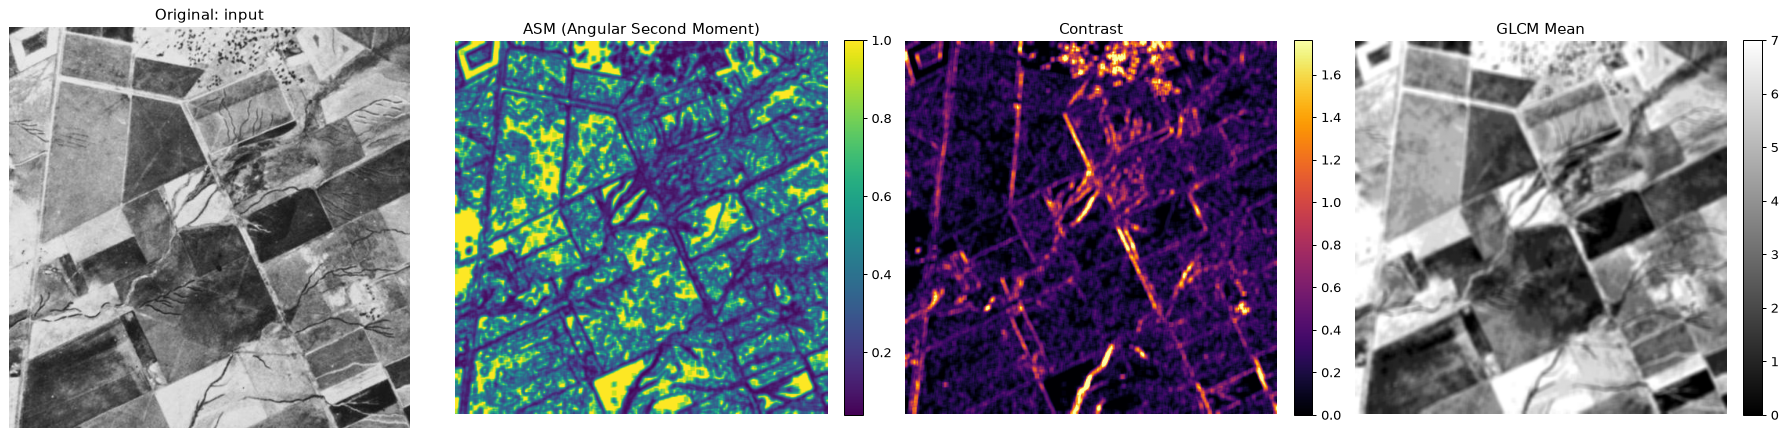

In [8]:
plot_texture_set(results["original"], limits, show=True)

## 8. K-Means methodology

Each pixel becomes a 3-D feature vector, and the $H\cdot W$ vectors form an $N \times 3$ matrix $X$:

$$ \mathbf{x}_{(x,y)} = [\,\mathrm{ASM}(x,y),\ \mathrm{CON}(x,y),\ \mathrm{MEAN}(x,y)\,]. $$

**Standardisation.** The features have very different ranges (ASM in [0,1], MEAN in [0,7]).
Each column is converted to z-scores so that no feature dominates the Euclidean distance:

$$ z_f = \frac{x_f - \bar{x}_f}{\sigma_f}. $$

**K-Means** (`sklearn.cluster.KMeans`, $K=4$, `n_init=10`, `random_state=0`) minimises the within-cluster sum of squares

$$ J = \sum_{k=1}^{K} \sum_{\mathbf{z} \in C_k} \lVert \mathbf{z} - \boldsymbol{\mu}_k \rVert^2 . $$

**Consistent labels.** K-Means numbers its clusters arbitrarily. After clustering, the clusters are
renumbered in ascending order of their centre's MEAN (darkest = 0, brightest = K-1), and the same
colours are used throughout, so cluster colours are comparable between experiments.
Centres are reported in the original feature units.

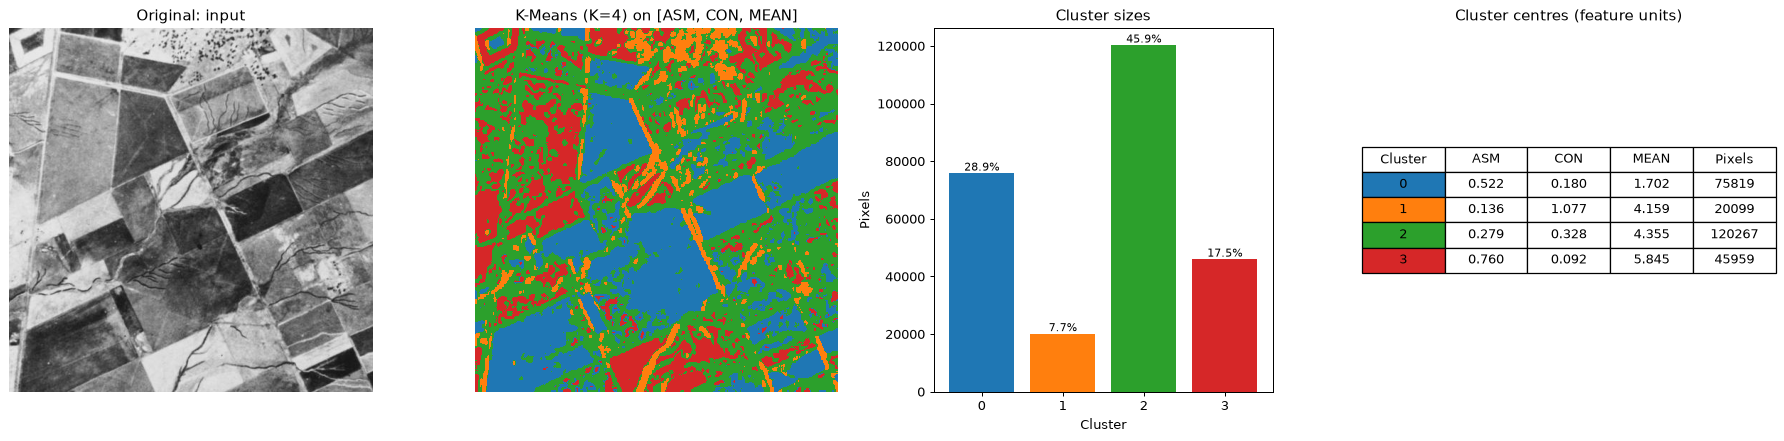

In [9]:
plot_clusters(results["original"], show=True)

## 9. Smoothing methodology

The original image is smoothed with a manually implemented mean (box) filter:

$$ I_{s}(x,y) = \frac{1}{N} \sum_{i=-a}^{a}\sum_{j=-a}^{a} I(x+i,\, y+j), \qquad N = (2a+1)^2, $$

with $2a+1 = 7$ ($N = 49$) and $2a+1 = 9$ ($N = 81$). The filter is implemented with an integral image
on a reflect-padded copy, so every output pixel averages exactly $N$ pixels and the output has the
input's size.

The box filter is a low-pass filter. Its frequency response is a 2-D sinc whose first zero lies at
spatial frequency $1/n$ cycles per pixel, so the larger filter removes a wider band of high frequencies.

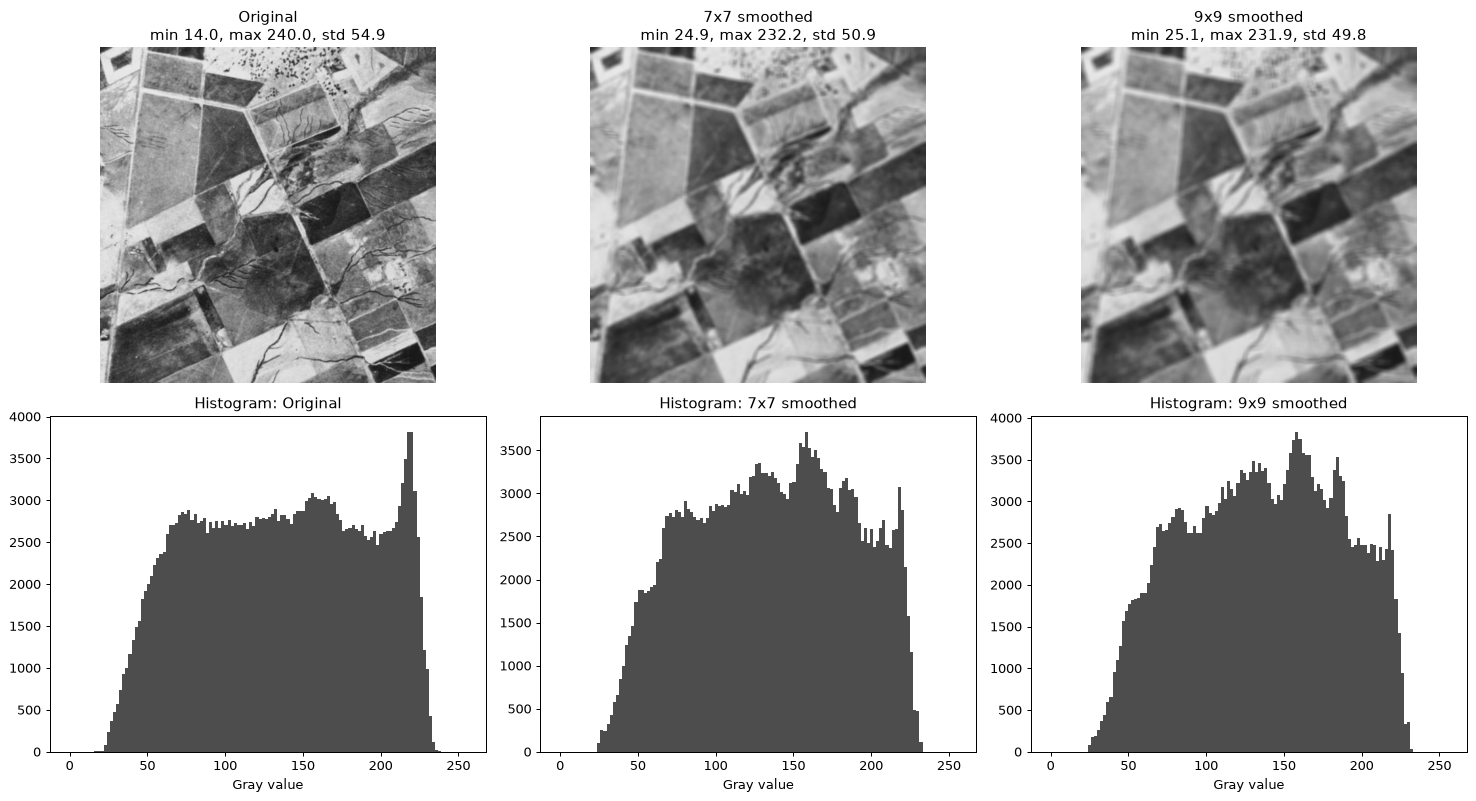

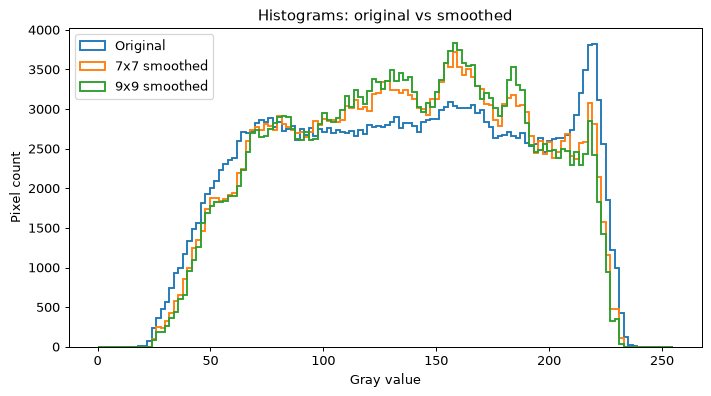

In [10]:
images = {c["label"]: c["image"] for c in results.values()}
plot_smoothing(images, show=True)
plot_histograms(images, show=True)

### 9.1 Texture images and clusters after smoothing

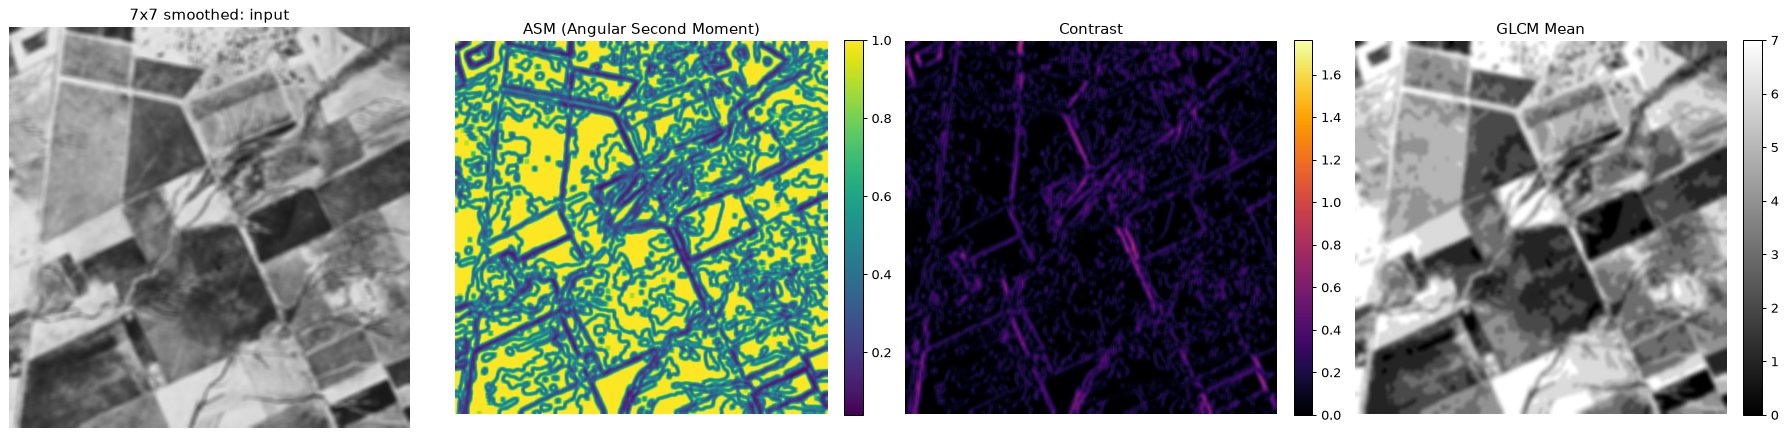

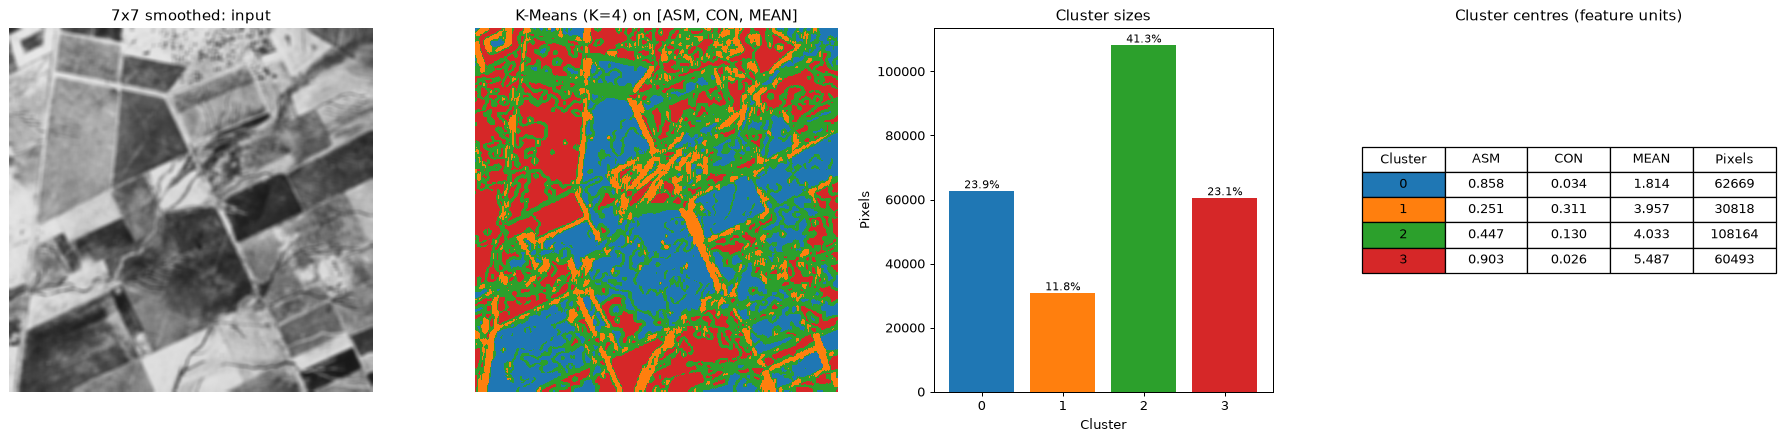

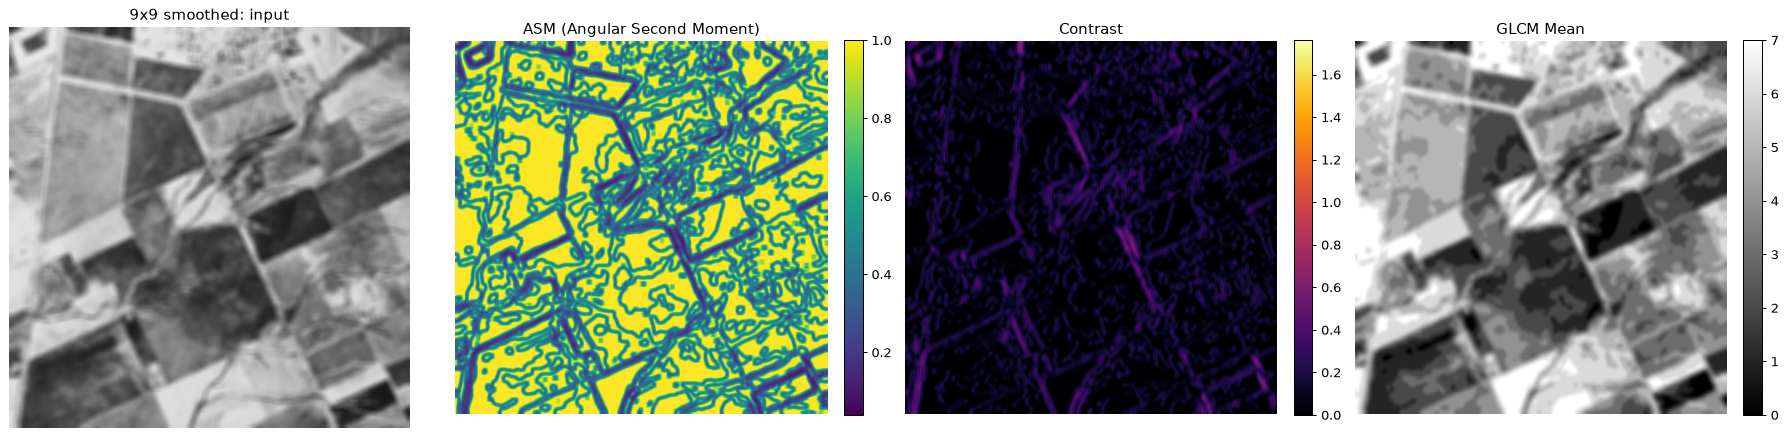

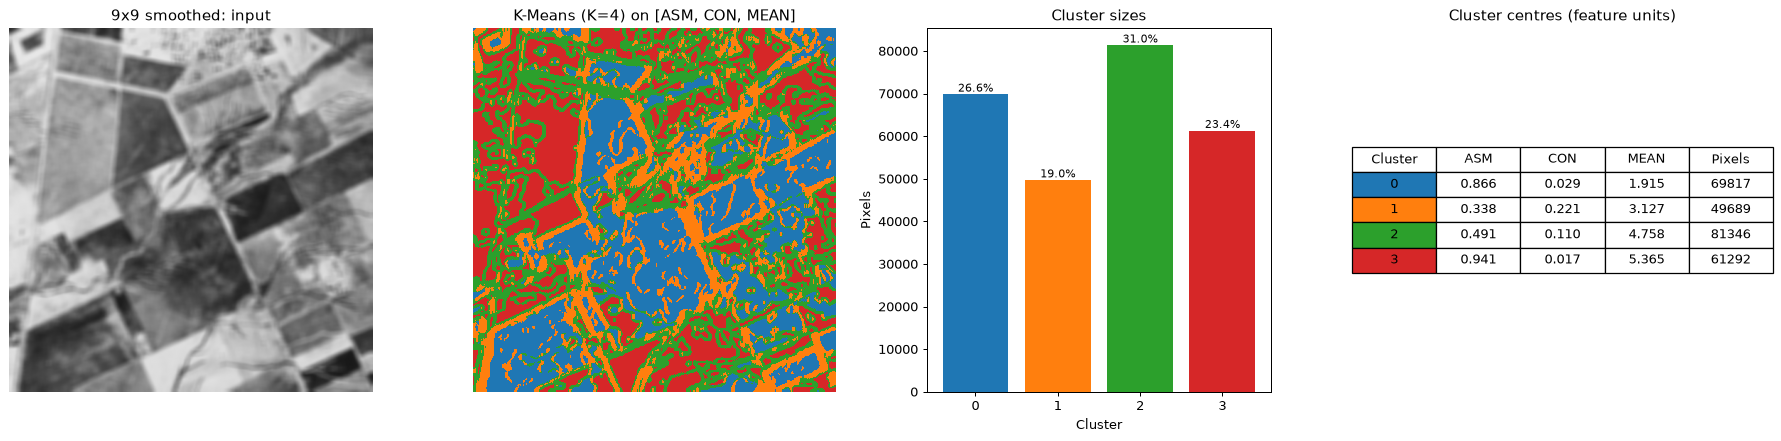

In [11]:
for key in list(results)[1:]:
    plot_texture_set(results[key], limits, show=True)
    plot_clusters(results[key], show=True)

## 10. Results

### 10.1 Texture-feature statistics

In [12]:
display(feature_stats)
display(feature_stats.pivot(index="Feature", columns="Case", values=["Mean", "Std"])
        .reindex(columns=[c["label"] for c in results.values()], level=1))

,Case,Feature,Min,Max,Mean,Std
0,Original,ASM,0.0397,1.0000,0.4223,0.2480
1,Original,CON,0.0000,3.7857,0.3014,0.2864
2,Original,MEAN,0.0000,7.0000,3.8319,1.8264
3,7x7 smoothed,ASM,0.0828,1.0000,0.6273,0.2774
4,7x7 smoothed,CON,0.0000,0.8333,0.1041,0.1022
5,7x7 smoothed,MEAN,0.0000,7.0000,3.8302,1.7717
6,9x9 smoothed,ASM,0.1020,1.0000,0.6667,0.2737
7,9x9 smoothed,CON,0.0000,0.6905,0.0879,0.0909
8,9x9 smoothed,MEAN,0.0000,7.0000,3.8326,1.7460


Mean                                Std                          
Case    Original 7x7 smoothed 9x9 smoothed Original 7x7 smoothed 9x9 smoothed
Feature                                                                      
ASM       0.4223       0.6273       0.6667   0.2480       0.2774       0.2737
CON       0.3014       0.1041       0.0879   0.2864       0.1022       0.0909
MEAN      3.8319       3.8302       3.8326   1.8264       1.7717       1.7460

### 10.2 Cluster statistics

Clusters are numbered by increasing MEAN centre. Centres are given in original feature units.

In [13]:
display(cluster_stats)
display(cluster_stats.pivot(index="Cluster", columns="Case", values="Percent")
        [[c["label"] for c in results.values()]].rename_axis(columns="Percent of image"))

,Case,Cluster,Pixels,Percent,Center_ASM,Center_CON,Center_MEAN
0,Original,0,75819,28.9227,0.5216,0.1801,1.7016
1,Original,1,20099,7.6672,0.1362,1.0774,4.1587
2,Original,2,120267,45.8782,0.2789,0.3277,4.3552
3,Original,3,45959,17.5320,0.7600,0.0920,5.8453
4,7x7 smoothed,0,62669,23.9063,0.8578,0.0339,1.8143
5,7x7 smoothed,1,30818,11.7561,0.2514,0.3107,3.9565
6,7x7 smoothed,2,108164,41.2613,0.4472,0.1296,4.0327
7,7x7 smoothed,3,60493,23.0762,0.9033,0.0255,5.4873
8,9x9 smoothed,0,69817,26.6331,0.8660,0.0290,1.9151
9,9x9 smoothed,1,49689,18.9548,0.3380,0.2212,3.1273


Percent of image,Original,7x7 smoothed,9x9 smoothed
Cluster,,,
0,28.9227,23.9063,26.6331
1,7.6672,11.7561,18.9548
2,45.8782,41.2613,31.0310
3,17.5320,23.0762,23.3810


### 10.3 Additional comparison metrics

* **High-freq energy:** mean squared difference between neighbouring pixels of the input.
* **Level transitions %:** neighbouring pixel pairs whose quantised levels differ.
* **Single-step transitions %:** share of those differences that are exactly one level.
* **Uniform windows %:** windows with ASM = 1. **Zero-contrast windows %:** windows with CON = 0.
* **Distinct vectors:** number of different $[ASM, CON, MEAN]$ vectors in the image.
* **Cluster boundary pixels %:** pixels with a 4-neighbour in a different cluster (fragmentation).
* **Effective no. of clusters:** $e^{H}$ of the cluster-size distribution.
* **ARI vs original:** Adjusted Rand Index between the cluster maps (1 = identical partition).
* **MAE of MEAN:** mean absolute difference from the original MEAN image.

In [14]:
display(metrics.set_index("Case").T)

Case,Original,7x7 smoothed,9x9 smoothed
High-freq energy,156.8151,21.8611,15.1490
Image std,54.8908,50.8596,49.8269
Level transitions %,26.4775,11.1577,9.4052
Single-step transitions %,92.6949,100.0000,100.0000
Uniform windows (ASM=1) %,4.8573,23.0534,27.7351
Zero-contrast windows %,4.8870,23.7942,28.7106
"Distinct [ASM,CON,MEAN] vectors",154730.0000,69810.0000,54107.0000
Cluster boundary pixels %,23.9368,31.5662,30.4935
Effective no. of clusters,3.3819,3.6599,3.9373
ARI vs original,1.0000,0.2877,0.2537


## 11. Final comparison

Rows: input, ASM, Contrast, Mean, K-Means. Columns: Original, 7x7 smoothed, 9x9 smoothed.
Each feature row uses one shared colour scale.

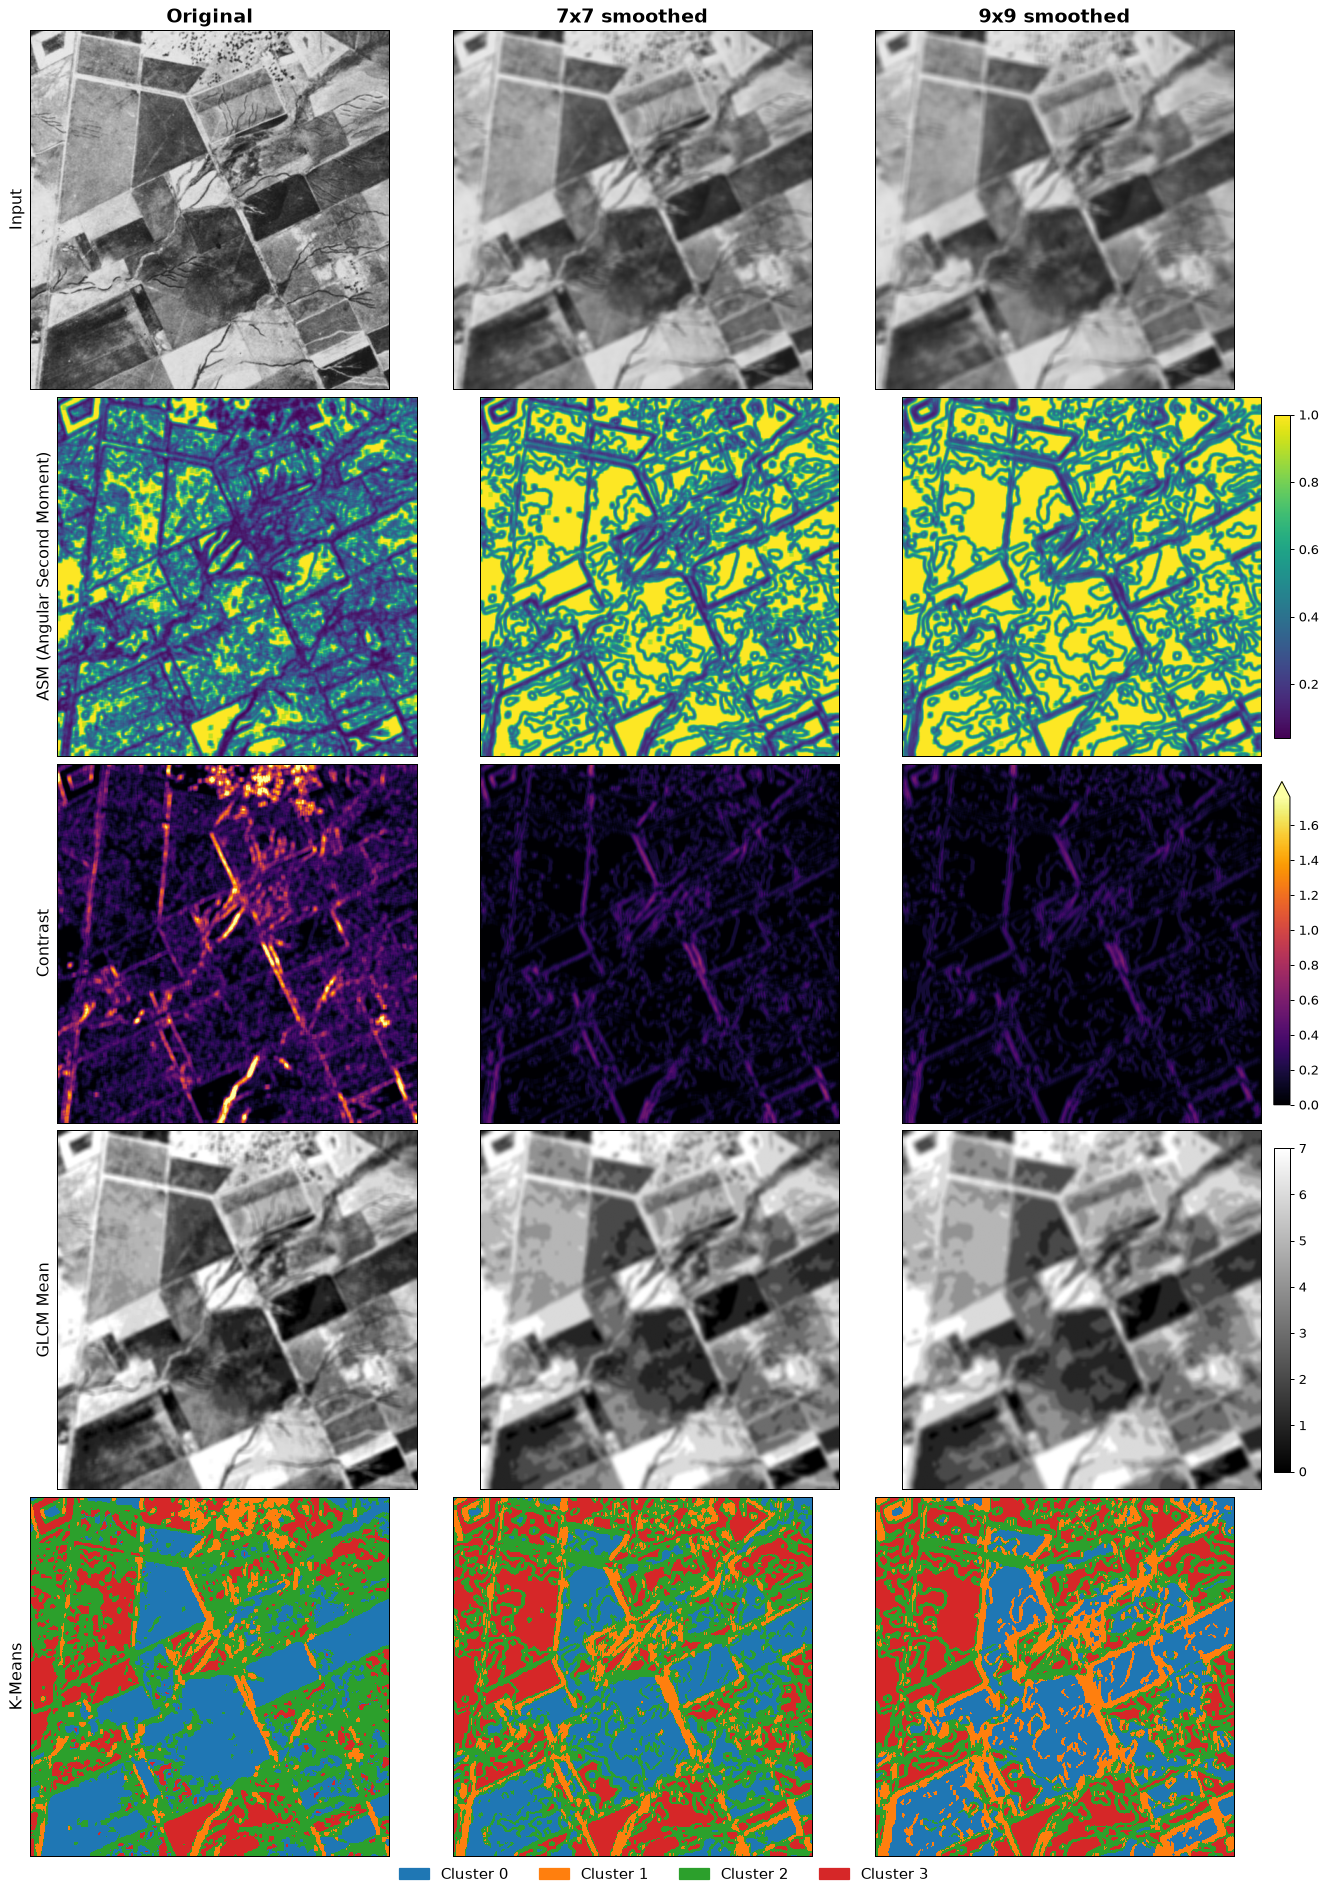

In [15]:
plot_comparison_grid(results, show=True)

## 12. Effect of smoothing on texture (automatically generated from the results)

The text below is generated by `analysis.interpret_results`. Each increase/decrease statement is
derived from the computed statistics, not assumed in advance.

In [16]:
display(Markdown(interpretation))

### Effect of smoothing on the image
The neighbour-difference (high-frequency) energy of the image decreased from 156.82 to 21.86 (-86.1%) after 7x7 averaging and decreased from 156.82 to 15.15 (-90.3%) after 9x9 averaging. The image standard deviation went from 54.89 to 50.86 (7x7) and 49.83 (9x9). A box filter of size n replaces each pixel by the mean of N = n^2 pixels (N = 49 vs 81); its frequency response has a narrower main lobe for larger n, so the 9x9 filter suppresses more fine detail and noise than the 7x7 filter.

### Effect on ASM (texture uniformity)
Mean ASM increased from 0.4223 to 0.6273 (+48.5%) with 7x7 smoothing and increased from 0.4223 to 0.6667 (+57.9%) with 9x9 smoothing. The share of perfectly uniform windows (ASM = 1, a single gray-level pair) was 4.9% / 23.1% / 27.7%. Smoothing therefore increased local texture uniformity: averaging pulls neighbouring pixels towards the same value, so within a window they fall into fewer quantised levels, the GLCM probability mass concentrates in a few (mainly diagonal) cells, and the sum of squared probabilities grows. The larger window gives the stronger effect.

### Effect on Contrast
Mean contrast decreased from 0.3014 to 0.1041 (-65.5%) (7x7) and decreased from 0.3014 to 0.0879 (-70.8%) (9x9); the maximum contrast went from 3.786 to 0.833 and 0.690. Windows with zero contrast (all pairs on the GLCM diagonal) made up 4.9% / 23.8% / 28.7% of the image. Averaging neighbouring pixels makes adjacent values nearly equal, so the quantised pairs (i, j) at distance 1 move towards the diagonal i = j where the weight (i - j)^2 is zero or small. Contrast falls, and falls further for the larger filter.

### Effect on Mean
The image-wide average of the GLCM mean was 3.832 / 3.830 / 3.833 (largest relative change 0.0%), i.e. it remained practically unchanged: an averaging filter preserves the local mean intensity (its kernel sums to one), so the average gray level of a window is largely conserved. The spatial variability of the MEAN image, however, decreased from 1.8264 to 1.7717 (-3.0%) (7x7) and decreased from 1.8264 to 1.7460 (-4.4%) (9x9); the mean absolute per-pixel difference from the original MEAN image is 0.155 and 0.210 gray levels. The MEAN image becomes a blurrier version of the original, with extremes near bright/dark features pulled towards their surroundings.

### Effect on K-Means clustering
- **Distinct texture patterns:** the number of distinct [ASM, CON, MEAN] vectors decreased from 154730 to 69810 (-54.9%) (7x7) and decreased from 154730 to 54107 (-65.0%) (9x9). Smoothing reduced the variety of texture patterns available to the classifier.
- **Homogeneity / boundaries:** the fraction of pixels on a cluster boundary was 23.9% / 31.6% / 30.5%. Within regions, homogeneity clearly increased: the share of perfectly uniform windows rose from 4.9% to 23.1% / 27.7%. Nevertheless the cluster maps did not become less fragmented. After smoothing, adjacent quantised levels differ at only 11.2% / 9.4% of neighbour pairs (original 26.5%), and 100% / 100% of those differences are single-level steps (original 93%). The remaining non-zero contrast is therefore concentrated in narrow bands where a window straddles a quantisation threshold of a smooth intensity ramp (iso-intensity contours). K-Means separates these thin bands from the uniform interiors, so they appear as elongated strips that add boundary pixels. This is a side effect of combining smoothing with coarse gray-level quantisation rather than real texture.
- **Cluster sizes:** original [28.9%, 7.7%, 45.9%, 17.5%], 7x7 [23.9%, 11.8%, 41.3%, 23.1%], 9x9 [26.6%, 19.0%, 31.0%, 23.4%] (clusters ordered by increasing MEAN centre). The effective number of clusters (exp of the size entropy) was 3.38 / 3.66 / 3.94, so the pixels are spread more evenly over the K classes after smoothing (largest cluster: 45.9% / 41.3% / 31.0%). Once fine texture is removed, the feature space is organised mainly by brightness (MEAN) and by the uniform-interior versus transition-band distinction, which splits the image into more balanced groups.
- **Changed boundaries:** the Adjusted Rand Index between the original map and the smoothed maps is 0.288 (7x7) and 0.254 (9x9) (1 = identical partition). Agreement drops as the filter grows, so the larger filter changes cluster membership and boundaries more.
- **Small / high-frequency structures:** thin features narrower than the filter (field boundaries, drainage lines, isolated trees) are averaged with their surroundings, so their high-contrast, low-ASM signature disappears and they are absorbed into the neighbouring clusters; distinct regions with similar mean brightness become more alike because their texture differences are what smoothing removes.

### 7x7 versus 9x9
Relative to 7x7, did the 9x9 filter give lower high-frequency energy: yes; lower mean contrast: yes; higher mean ASM: yes; fewer cluster-boundary pixels: yes; fewer distinct feature vectors: yes. All indicators confirm that the 9x9 window produces the stronger smoothing effect, because each output pixel averages 81 instead of 49 values, cancelling more of the local variation that GLCM texture measures.

## 13. Conclusion

In [17]:
fs = feature_stats.set_index(["Case", "Feature"])["Mean"]
m = metrics.set_index("Case")
L0, L1, L2 = [c["label"] for c in results.values()]
pc = lambda a, b: 100 * (b - a) / a
n_stronger = sum([m.loc[L2, "High-freq energy"] < m.loc[L1, "High-freq energy"],
                  fs[(L2, "CON")] < fs[(L1, "CON")], fs[(L2, "ASM")] > fs[(L1, "ASM")],
                  m.loc[L2, "Cluster boundary pixels %"] < m.loc[L1, "Cluster boundary pixels %"],
                  m.loc[L2, "Distinct [ASM,CON,MEAN] vectors"] < m.loc[L1, "Distinct [ASM,CON,MEAN] vectors"]])
conclusion = f'''
* A moving-window GLCM ({GLCM_WINDOW_SIZE}x{GLCM_WINDOW_SIZE} window, {GRAY_LEVELS} gray levels,
  offset {OFFSET}) was implemented from scratch. A **separate GLCM is built and normalised for every
  one of the {image.size:,} window positions**, and ASM, Contrast and Mean are computed from it.
  A vectorised version was verified to give results identical to the naive per-window loop.
* On the original aerial image the texture images separate uniform fields (high ASM, low contrast)
  from tree-covered and textured areas, field boundaries and drainage lines (low ASM, high contrast).
  K-Means on the standardised $[ASM, CON, MEAN]$ vectors turns this into a {NUM_CLUSTERS}-class texture map.
* **Smoothing** changed mean ASM by {pc(fs[(L0,'ASM')], fs[(L1,'ASM')]):+.1f}% (7x7) and
  {pc(fs[(L0,'ASM')], fs[(L2,'ASM')]):+.1f}% (9x9), and mean Contrast by
  {pc(fs[(L0,'CON')], fs[(L1,'CON')]):+.1f}% and {pc(fs[(L0,'CON')], fs[(L2,'CON')]):+.1f}%.
  The average Mean changed by only {pc(fs[(L0,'MEAN')], fs[(L1,'MEAN')]):+.2f}% and
  {pc(fs[(L0,'MEAN')], fs[(L2,'MEAN')]):+.2f}%: averaging preserves brightness but removes the
  local gray-level variation that GLCM texture measures.
* The variety of texture patterns dropped from {m.loc[L0,'Distinct [ASM,CON,MEAN] vectors']:,} distinct
  feature vectors to {m.loc[L1,'Distinct [ASM,CON,MEAN] vectors']:,} (7x7) and
  {m.loc[L2,'Distinct [ASM,CON,MEAN] vectors']:,} (9x9). The K-Means partitions agree with the original
  only partly (ARI {m.loc[L1,'ARI vs original']:.2f} and {m.loc[L2,'ARI vs original']:.2f}): after smoothing,
  clusters reflect brightness and broad regions instead of fine texture. Small structures such as
  drainage lines and individual trees are no longer separate texture classes.
* The **9x9 filter** (N = 81) had a stronger effect than the **7x7 filter** (N = 49) on
  {n_stronger} of 5 indicators (high-frequency energy, mean contrast, mean ASM, cluster-boundary
  pixels, distinct feature vectors), because it averages more pixels and passes a narrower band of
  spatial frequencies.
* Practical implication: smoothing before GLCM analysis suppresses noise but also destroys the
  texture being measured. The smoothing window should be clearly smaller than the texture scale
  of interest, otherwise GLCM features mostly describe brightness and quantisation boundaries.
'''
display(Markdown(conclusion))


* A moving-window GLCM (7x7 window, 8 gray levels,
  offset (0, 1)) was implemented from scratch. A **separate GLCM is built and normalised for every
  one of the 262,144 window positions**, and ASM, Contrast and Mean are computed from it.
  A vectorised version was verified to give results identical to the naive per-window loop.
* On the original aerial image the texture images separate uniform fields (high ASM, low contrast)
  from tree-covered and textured areas, field boundaries and drainage lines (low ASM, high contrast).
  K-Means on the standardised $[ASM, CON, MEAN]$ vectors turns this into a 4-class texture map.
* **Smoothing** changed mean ASM by +48.5% (7x7) and
  +57.9% (9x9), and mean Contrast by
  -65.5% and -70.8%.
  The average Mean changed by only -0.04% and
  +0.02%: averaging preserves brightness but removes the
  local gray-level variation that GLCM texture measures.
* The variety of texture patterns dropped from 154,730 distinct
  feature vectors to 69,810 (7x7) and
  54,107 (9x9). The K-Means partitions agree with the original
  only partly (ARI 0.29 and 0.25): after smoothing,
  clusters reflect brightness and broad regions instead of fine texture. Small structures such as
  drainage lines and individual trees are no longer separate texture classes.
* The **9x9 filter** (N = 81) had a stronger effect than the **7x7 filter** (N = 49) on
  5 of 5 indicators (high-frequency energy, mean contrast, mean ASM, cluster-boundary
  pixels, distinct feature vectors), because it averages more pixels and passes a narrower band of
  spatial frequencies.
* Practical implication: smoothing before GLCM analysis suppresses noise but also destroys the
  texture being measured. The smoothing window should be clearly smaller than the texture scale
  of interest, otherwise GLCM features mostly describe brightness and quantisation boundaries.
